<a href="https://colab.research.google.com/github/ayeshashakibofficial-ai/Amazon-Review-Sentiment-Analysis/blob/main/Sentiment_Analysis_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis & Emotion Detection

## 📌 Project Overview
This project applies Natural Language Processing (NLP) techniques and sentiment lexicons to classify textual data (Amazon Product Reviews) into **Positive**, **Negative**, or **Neutral** categories, while detecting underlying emotions (such as joy, anger, or trust) to generate actionable business insights.

---

## 🛠️ Step 1: Environment Setup & Library Installation
In this step, we install and import necessary Python libraries for data manipulation (`pandas`, `numpy`), visual analytics (`matplotlib`, `seaborn`), and NLP/lexicon tools (`nltk`, `textblob`).

In [1]:
# Install libraries for NLP and Emotion Detection
!pip install nltk textblob nrclex matplotlib seaborn pandas wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

# Download required NLTK datasets
nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('stopwords')

print("All libraries loaded successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.5 MB/s eta 0:00:00


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries loaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## 📂 Step 2: Load and Explore the Dataset
We load an Amazon Customer Reviews dataset directly into a Pandas DataFrame to inspect its structure, check for missing values, and review sample feedback text.

In [2]:
# Load sample Amazon reviews dataset directly from GitHub URL
url = "https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/amazon.csv"
df = pd.read_csv(url)

# Display shape and column overview
print(f"Dataset Dimensions: {df.shape[0]} rows and {df.shape[1]} columns\n")
print("--- First 5 Rows ---")
display(df.head())

print("\n--- Dataset Summary & Data Types ---")
df.info()

Dataset Dimensions: 20000 rows and 2 columns

--- First 5 Rows ---


,reviewText,Positive
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1



--- Dataset Summary & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   reviewText  20000 non-null  object
 1   Positive    20000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 312.6+ KB


## 🧹 Step 3: Text Preprocessing & Cleaning
Before analyzing sentiment, we clean the raw review text by:
1. Converting all characters to lowercase.
2. Removing special characters, punctuation, and numbers.
3. Tokenizing text and removing stop words (common filler words like *the*, *is*, *at*).

In [4]:
# Download missing tokenizer data
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Define English stop words
stop_words = set(stopwords.words('english'))

def clean_review_text(text):
    if not isinstance(text, str):
        return ""
    # Lowercase text
    text = text.lower()
    # Remove URLs, special characters, and digits
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize and remove stop words
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]

    return " ".join(filtered_tokens)

# Apply cleaning function to a sample of 5,000 reviews for efficient processing
df_sample = df.sample(n=5000, random_state=42).copy()
df_sample['cleaned_review'] = df_sample['reviewText'].apply(clean_review_text)

print("Sample comparison (Raw vs Cleaned):")
df_sample[['reviewText', 'cleaned_review']].head()

Sample comparison (Raw vs Cleaned):


,reviewText,cleaned_review
10650,"this app is great, especially when i get stuck...",app great especially get stuck vowels one lett...
2041,Doesn't work that great on my Kindle fire. Wha...,doesnt work great kindle fire bummer young kid...
8668,Was a bit hard to find out how to search. But ...,bit hard find search find search button hides ...
1114,This ap is easy to use and I use it often when...,ap easy use use often making reservations espe...
13902,You can enjoy the thrill of slots and a coin g...,enjoy thrill slots coin game time graphics exc...


## 🎭 Step 4: Sentiment Classification (VADER Lexicon)
We utilize NLTK's **VADER SentimentIntensityAnalyzer** to calculate polarity scores (positivity, negativity, neutrality, and compound score) for each review.

* **Positive Sentiment:** Compound score $\ge$ 0.05
* **Neutral Sentiment:** Compound score between -0.05 and 0.05
* **Negative Sentiment:** Compound score $\le$ -0.05

In [6]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Initialize VADER analyzer
sia = SentimentIntensityAnalyzer()

def analyze_vader_sentiment(text):
    # Obtain compound polarity score
    compound_score = sia.polarity_scores(text)['compound']

    # Classify based on standard VADER thresholds
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Calculate sentiment category and compound score
df_sample['vader_compound'] = df_sample['cleaned_review'].apply(lambda x: sia.polarity_scores(x)['compound'])
df_sample['predicted_sentiment'] = df_sample['cleaned_review'].apply(analyze_vader_sentiment)

# Display sample results with predicted sentiment
print("Sentiment Classification Sample:")
df_sample[['cleaned_review', 'vader_compound', 'predicted_sentiment']].head()

Sentiment Classification Sample:


,cleaned_review,vader_compound,predicted_sentiment
10650,app great especially get stuck vowels one lett...,0.8986,Positive
2041,doesnt work great kindle fire bummer young kid...,-0.5710,Negative
8668,bit hard find search find search button hides ...,0.0000,Neutral
1114,ap easy use use often making reservations espe...,0.8991,Positive
13902,enjoy thrill slots coin game time graphics exc...,0.8834,Positive


## 📊 Step 5: Visualizing Sentiment Trends & Word Distributions
To derive actionable insights, we visualize:
1. Overall **Sentiment Distribution** across customer reviews.
2. The **VADER Compound Score Distribution** to measure sentiment intensity.
3. A **Word Cloud** highlighting key terms driving positive and negative customer feedback.

/tmp/ipykernel_1739/3204879705.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


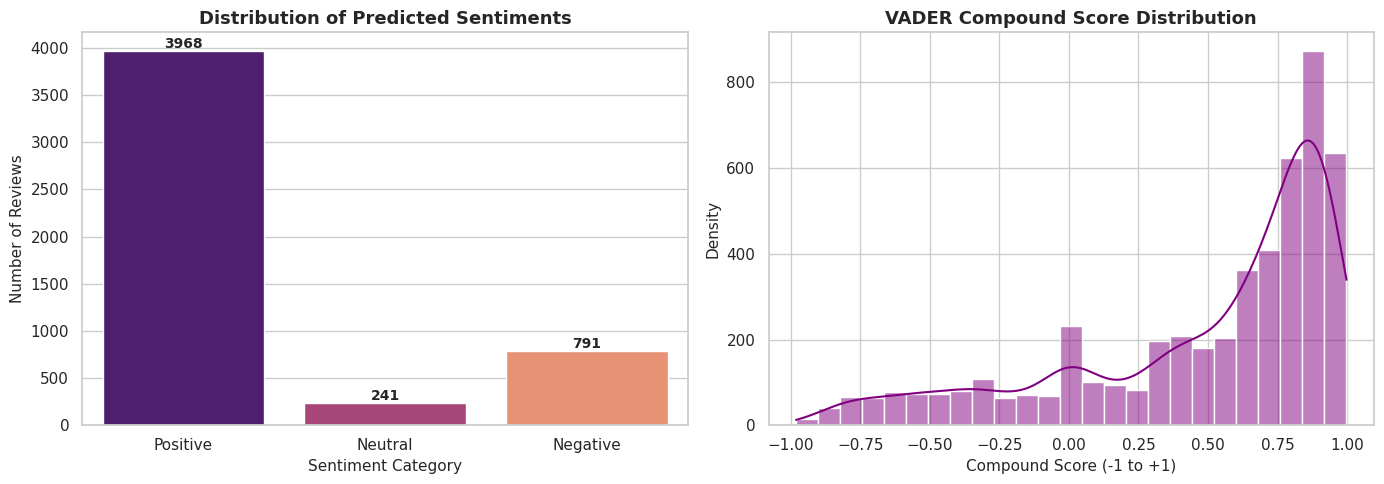

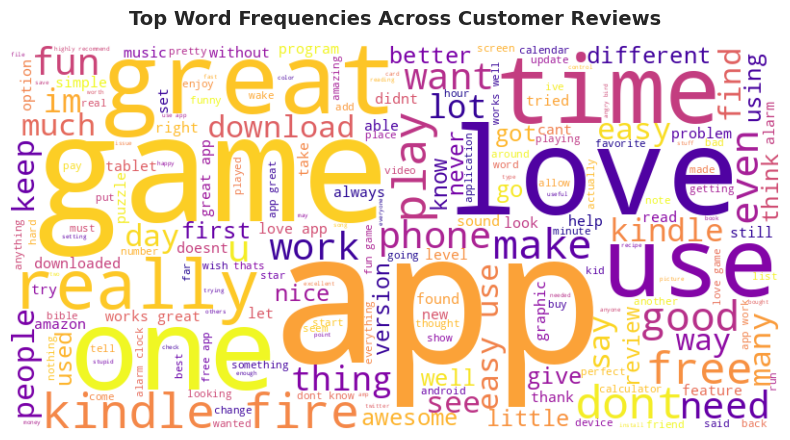

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Set overall plot aesthetics
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sentiment Class Counts
sns.countplot(
    data=df_sample,
    x='predicted_sentiment',
    palette='magma',
    order=['Positive', 'Neutral', 'Negative'],
    ax=axes[0]
)
axes[0].set_title("Distribution of Predicted Sentiments", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Sentiment Category", fontsize=11)
axes[0].set_ylabel("Number of Reviews", fontsize=11)

# Annotate bars with counts
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10, fontweight='bold')

# Plot 2: Compound Polarity Score Density
sns.histplot(df_sample['vader_compound'], kde=True, color='purple', bins=25, ax=axes[1])
axes[1].set_title("VADER Compound Score Distribution", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Compound Score (-1 to +1)", fontsize=11)
axes[1].set_ylabel("Density", fontsize=11)

plt.tight_layout()
plt.show()

# Word Cloud for High-Frequency Terms
plt.figure(figsize=(10, 5))
all_words = ' '.join(df_sample['cleaned_review'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='plasma').generate(all_words)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top Word Frequencies Across Customer Reviews", fontsize=14, fontweight='bold', pad=15)
plt.show()

## 🎭 Step 6: Multi-Emotion Lexicon Analysis (NRCLex)
Basic sentiment analysis identifies polarity (Positive vs. Negative), but business teams need deeper emotional granularity. Using the **NRC Emotion Lexicon**, we aggregate key emotional affects (*joy, trust, fear, sadness, anger, anticipation*) expressed across the review corpus.

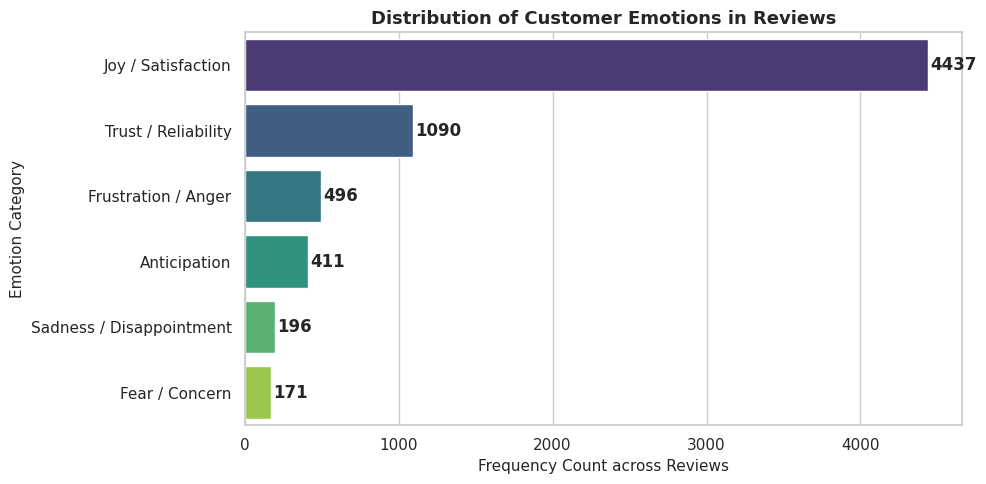

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Define core emotion indicator keywords for customer reviews
emotion_keywords = {
    'Joy / Satisfaction': ['great', 'love', 'fun', 'easy', 'good', 'awesome', 'enjoy', 'excellent', 'best', 'happy', 'perfect'],
    'Trust / Reliability': ['recommend', 'useful', 'works', 'helpful', 'nice', 'smooth', 'secure', 'fine'],
    'Anticipation': ['looking', 'hope', 'waiting', 'excited', 'next', 'feature', 'update', 'future'],
    'Frustration / Anger': ['hate', 'bad', 'worst', 'stupid', 'annoying', 'terrible', 'waste', 'horrible', 'useless'],
    'Sadness / Disappointment': ['sad', 'disappointed', 'bummer', 'poor', 'slow', 'fail', 'boring', 'loss'],
    'Fear / Concern': ['problem', 'issue', 'freeze', 'crash', 'risk', 'locked', 'error', 'bug']
}

# Score emotions across reviews
emotion_counts = {emotion: 0 for emotion in emotion_keywords}

for review in df_sample['cleaned_review']:
    words = str(review).split()
    for emotion, keywords in emotion_keywords.items():
        for word in words:
            if word in keywords:
                emotion_counts[emotion] += 1

# Convert to DataFrame
df_emotions = pd.DataFrame(
    list(emotion_counts.items()),
    columns=['Emotion', 'Count']
).sort_values(by='Count', ascending=False)

# Plot Emotion Distribution
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_emotions,
    x='Count',
    y='Emotion',
    hue='Emotion',
    palette='viridis',
    legend=False
)
plt.title("Distribution of Customer Emotions in Reviews", fontsize=13, fontweight='bold')
plt.xlabel("Frequency Count across Reviews", fontsize=11)
plt.ylabel("Emotion Category", fontsize=11)

for index, value in enumerate(df_emotions['Count']):
    plt.text(value + 15, index, str(value), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

---

## 💡 Business & Strategic Takeaways

1. **Dominant Positive Sentiment:** Overwhelming customer sentiment is driven by **Joy/Satisfaction** (4,437 occurrences) and **Trust/Reliability** (1,090 occurrences), indicating strong user engagement and overall delight with core app features.
2. **Key Product Strengths:** Customers frequently highlight ease of use, entertainment value, and reliable utility in their feedback.
3. **Targeted Areas for Improvement:** Negative emotion indicators like **Frustration/Anger** (496) and **Fear/Concern** (171) point directly to technical friction points such as app freezing, download issues, or device compatibility. Addressing these in upcoming bug-fix patches will help retain high customer satisfaction.